## Examen de Primer Bimestre de RI

#### Nombre: Francisco Hernandez
#### Fecha: 27/05/2026

### 0.Instalacion de librerias

In [34]:
import subprocess, sys
for pkg in ['sentence-transformers', 'scikit-learn', 'pandas', 'numpy', 'nltk', 'tqdm', 'matplotlib']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('Dependencias listas')


Dependencias listas


In [12]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

nltk.download('stopwords', quiet=True)

True

## 1. Carga del Corpus

Se cargan las reseñas del dataset Rotten Tomatoes y se cruzan con la tabla de películas para obtener los títulos.

In [18]:
reviews = pd.read_csv('corpus_examen/rotten_tomatoes_critic_reviews.csv')
movies  = pd.read_csv('corpus_examen/rotten_tomatoes_movies.csv')[['rotten_tomatoes_link', 'movie_title']]

# muestra limitada a 5000 reseñas
reviews = reviews.dropna(subset=['review_content']).sample(n=5000, random_state=42).reset_index(drop=True)
corpus  = reviews.merge(movies, on='rotten_tomatoes_link', how='left')
corpus['movie_title'] = corpus['movie_title'].fillna('Unknown')
corpus  = corpus.reset_index(drop=True)

print('Reseñas cargadas:', len(corpus))
corpus[['movie_title', 'review_content']].head(3)

Reseñas cargadas: 5000


,movie_title,review_content
0,Snatched,"It's predictable stuff for the most part, and ..."
1,Eden,Though the film defines Paul's life by his rel...
2,Cold Fish,"Just as with Suicide Club, the deliberate weir..."


## 2. Preprocesamiento

Pipeline aplicado: minúsculas → eliminar URLs → eliminar puntuación → colapsar espacios → eliminar stopwords.

In [19]:
stop_en = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'https?\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(w for w in text.split() if w not in stop_en)

corpus['clean_text'] = corpus['review_content'].apply(preprocess)

print('Original :', corpus['review_content'].iloc[0][:120])
print('Procesado:', corpus['clean_text'].iloc[0][:120])

Original : It's predictable stuff for the most part, and the jokes thin out half way through, but Schumer and Hawn are great togeth
Procesado: predictable stuff part jokes thin half way schumer hawn great together schumer wrings every last drop laughter script


## 3. Generación de Embeddings

Se usa **Sentence Transformers** para generar una representación vectorial densa por reseña completa, no por palabra individual.

In [35]:
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Modelo: all-MiniLM-L6-v2 Dimensión:', model.get_sentence_embedding_dimension())

embeddings = model.encode(corpus['clean_text'].tolist(), batch_size=64, show_progress_bar=True)
print('Embeddings generados:', embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3981.76it/s]
C:\Users\Pancho\AppData\Local\Temp\ipykernel_14448\3643147959.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Modelo: all-MiniLM-L6-v2 Dimensión:', model.get_sentence_embedding_dimension())


Modelo: all-MiniLM-L6-v2 Dimensión: 384


Batches: 100%|██████████| 79/79 [00:24<00:00,  3.18it/s]

Embeddings generados: (5000, 384)


## 4. Sistema de Búsqueda por Similitud Coseno

In [36]:
def search(query, top_k=10, emb=None, mdl=None):
    if emb is None: emb = embeddings
    if mdl is None: mdl = model
    q_vec = mdl.encode([preprocess(query)])
    sims  = cosine_similarity(q_vec, emb)[0]
    top   = np.argsort(sims)[::-1][:top_k]
    return [{
        'rank':       int(r + 1),
        'doc_id':     int(i),
        'title':      corpus['movie_title'].iloc[i],
        'fragment':   corpus['review_content'].iloc[i][:150],
        'similarity': round(float(sims[i]), 4)
    } for r, i in enumerate(top)]

## 5. Consultas Benchmark

Se ejecutan las 8 consultas obligatorias con Top-7 resultados cada una.

In [37]:
queries = {
    'Q1': 'science fiction movie with advanced technology',
    'Q2': 'romantic story with emotional relationships',
    'Q3': 'action movie with intense fight scenes',
    'Q4': 'horror film that creates fear and suspense',
    'Q5': 'visually impressive movie with weak storyline',
    'Q6': 'emotionally moving performance by the lead actor',
    'Q7': 'predictable plot but entertaining experience',
    'Q8': 'movie praised by critics but unpopular with audiences'
}

results = {qid: search(q, top_k=7) for qid, q in queries.items()}


In [39]:
for qid, qtext in queries.items():
    df = pd.DataFrame(results[qid])[['rank', 'doc_id', 'title', 'fragment', 'similarity']]
    df.columns = ['Ranking', 'ID Documento', 'Título Película', 'Fragmento de Texto', 'Similitud Coseno']
    print('\n' + '-'*80)
    print(qid + ': ' + qtext)
    print('-'*80)
    display(df)


--------------------------------------------------------------------------------
Q1: science fiction movie with advanced technology
--------------------------------------------------------------------------------


,Ranking,ID Documento,Título Película,Fragmento de Texto,Similitud Coseno
0,1,4739,Moon,This excellent little science fiction film is ...,0.5554
1,2,2604,Transformers: Dark of the Moon,"These Transformer movies are nonsense, of cour...",0.5363
2,3,4854,After Earth,This is one of those movies where you suspect ...,0.5126
3,4,4656,Upgrade,Upgrade is a future-shock action horror film s...,0.5031
4,5,1017,Elysium,This is a big budget science fiction film with...,0.5028
5,6,130,Marshland (La isla mínima),"With each new discovery, the film becomes more...",0.4992
6,7,2761,Akira,Still one of the best techno science fiction t...,0.4916



--------------------------------------------------------------------------------
Q2: romantic story with emotional relationships
--------------------------------------------------------------------------------


,Ranking,ID Documento,Título Película,Fragmento de Texto,Similitud Coseno
0,1,4690,The Father of My Children (Le pere de mes enfa...,"Father is a very intimate film, and writer-dir...",0.5479
1,2,1251,Celeste and Jesse Forever,This romantic comedy is ambitious and thoughtf...,0.5393
2,3,2439,Red 2,RED 2 is perilously close to a formulaic roman...,0.5317
3,4,2991,Modern Life Is Rubbish,Exploring a relationship by flicking between b...,0.5172
4,5,3929,Warm Bodies,To call this an unlikely love story is an unde...,0.5166
5,6,4866,Seven Pounds,An unconvincing drama masquerading as a spirit...,0.5159
6,7,3333,No Strings Attached,"This being a Hollywood romantic comedy, the ou...",0.5127



--------------------------------------------------------------------------------
Q3: action movie with intense fight scenes
--------------------------------------------------------------------------------


...

,Ranking,ID Documento,Título Película,Fragmento de Texto,Similitud Coseno
0,1,1434,The Other Son,"A provocative, moving social drama, superbly t...",0.6309
1,2,1022,Hope Springs,"Mildly diverting, but far from either of its l...",0.6053
2,3,4813,The New Romantic,Clever writing and a solid lead actor will onl...,0.5774
3,4,4029,Love Actually,Whatever the actors are given to do they make ...,0.5366
4,5,467,Rain Man,Its end effect depends largely on one's suscep...,0.5304
5,6,1558,Wonderland,The film all too often has the feel of an acti...,0.5225
6,7,2727,The Ides of March,"Without anyone noticing, George Clooney has be...",0.5114



--------------------------------------------------------------------------------
Q7: predictable plot but entertaining experience
--------------------------------------------------------------------------------


,Ranking,ID Documento,Título Película,Fragmento de Texto,Similitud Coseno
0,1,613,Rainbow Time,"A movie that's admirably provocative, even if ...",0.6091
1,2,4133,Valiant,A disarmingly enjoyable movie with a lively ca...,0.5861
2,3,3710,Stage Fright,A film with this title and this plot descripti...,0.5741
3,4,3645,Sinbad: Legend of the Seven Seas,"The effects are competent, the action has exci...",0.5709
4,5,2276,Elysium,Depressingly predictable in its ideas and tedi...,0.5664
5,6,1980,Mutant Chronicles,"Mutant Chronicles has an intriguing premise, g...",0.5599
6,7,553,Dolphin Tale,The story is predictable and follows a well-wo...,0.5574



--------------------------------------------------------------------------------
Q8: movie praised by critics but unpopular with audiences
--------------------------------------------------------------------------------


,Ranking,ID Documento,Título Película,Fragmento de Texto,Similitud Coseno
0,1,4053,Shut In,Shut In is a very bad movie anchored by a very...,0.5833
1,2,1360,The Promotion,"I predict that when this film is released, lot...",0.5821
2,3,4249,Philomena,A small film that deserves a large audience.,0.5742
3,4,92,Rollerball,A movie of such rank stupidity and appalling t...,0.5710
4,5,1444,Harry Potter and the Deathly Hallows - Part 2,"If ever there was a critic-proof film, this is...",0.5680
5,6,1758,Teenage Mutant Ninja Turtles,Neither a particularly good movie nor the pop-...,0.5510
6,7,2744,Batman v Superman: Dawn of Justice,"The studio has, in the usual way, begged and b...",0.5404


In [42]:
summary = pd.DataFrame([{
    'Consulta':        qid,
    'Query':           queries[qid],
    'Documento Top1': results[qid][0]['doc_id'],
    'Título Película': results[qid][0]['title'],
    'Similitud Coseno':       results[qid][0]['similarity']
} for qid in sorted(queries)])

print('TABLA DE RESUMEN GENERAL - Top1 por consulta')
display(summary)
summary.to_csv('resultados_resumen.csv', index=False)

TABLA DE RESUMEN GENERAL - Top1 por consulta


,Consulta,Query,Documento Top1,Título Película,Similitud Coseno
0,Q1,science fiction movie with advanced technology,4739,Moon,0.5554
1,Q2,romantic story with emotional relationships,4690,The Father of My Children (Le pere de mes enfa...,0.5479
2,Q3,action movie with intense fight scenes,668,Captain America: Civil War,0.6266
3,Q4,horror film that creates fear and suspense,1433,The Abandoned,0.7247
4,Q5,visually impressive movie with weak storyline,4892,Aliens in the Attic,0.6500
5,Q6,emotionally moving performance by the lead actor,1434,The Other Son,0.6309
6,Q7,predictable plot but entertaining experience,613,Rainbow Time,0.6091
7,Q8,movie praised by critics but unpopular with au...,4053,Shut In,0.5833


## 6. Desafío de Excelencia

### 6.1 Comparación de dos modelos de embeddings

`all-MiniLM-L6-v2` (384 dim, rápido) vs `all-mpnet-base-v2` (768 dim, mayor calidad semántica) sobre las mismas 8 consultas.

In [31]:
model2 = SentenceTransformer('all-mpnet-base-v2')
print('Modelo 2: all-mpnet-base-v2  |  Dimensión:', model2.get_sentence_embedding_dimension())

embeddings2 = model2.encode(corpus['clean_text'].tolist(), batch_size=32, show_progress_bar=True)
print('Shape embeddings2:', embeddings2.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2217.68it/s]
C:\Users\Pancho\AppData\Local\Temp\ipykernel_14448\3184139561.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Modelo 2: all-mpnet-base-v2  |  Dimensión:', model2.get_sentence_embedding_dimension())


Modelo 2: all-mpnet-base-v2  |  Dimensión: 768


Batches: 100%|██████████| 157/157 [02:24<00:00,  1.09it/s]

Shape embeddings2: (5000, 768)


In [43]:
results2 = {qid: search(q, top_k=10, emb=embeddings2, mdl=model2) for qid, q in queries.items()}

comp = pd.DataFrame([{
    'Query':     qid,
    'M1 Título': results[qid][0]['title'],
    'M1 Sim':    results[qid][0]['similarity'],
    'M2 Título': results2[qid][0]['title'],
    'M2 Sim':    results2[qid][0]['similarity'],
    'Coinciden': results[qid][0]['doc_id'] == results2[qid][0]['doc_id']
} for qid in sorted(queries)])

print('Top-1 por consulta: all-MiniLM-L6-v2  vs  all-mpnet-base-v2')
display(comp)
print('Similitud promedio M1:', round(comp['M1 Sim'].mean(), 4))
print('Similitud promedio M2:', round(comp['M2 Sim'].mean(), 4))

Top-1 por consulta: all-MiniLM-L6-v2  vs  all-mpnet-base-v2


,Query,M1 Título,M1 Sim,M2 Título,M2 Sim,Coinciden
0,Q1,Moon,0.5554,Ghost in the Shell,0.6020,False
1,Q2,The Father of My Children (Le pere de mes enfa...,0.5479,Indignation,0.6306,False
2,Q3,Captain America: Civil War,0.6266,Iron Monkey,0.6511,False
3,Q4,The Abandoned,0.7247,Night of the Living Dead,0.7256,False
4,Q5,Aliens in the Attic,0.6500,Bobby Fischer Against The World,0.7166,False
5,Q6,The Other Son,0.6309,Bombshell,0.6235,False
6,Q7,Rainbow Time,0.6091,Dolphin Tale,0.6825,False
7,Q8,Shut In,0.5833,Leatherheads,0.6156,False


Similitud promedio M1: 0.616
Similitud promedio M2: 0.6559


### 6.2 Visualización de embeddings con PCA

Reducción a 2D para visualizar cómo se distribuyen los documentos recuperados por Q1–Q4 en el espacio vectorial de cada modelo. Las estrellas (★) representan los embeddings de la consulta; los círculos son los Top-5 documentos recuperados.

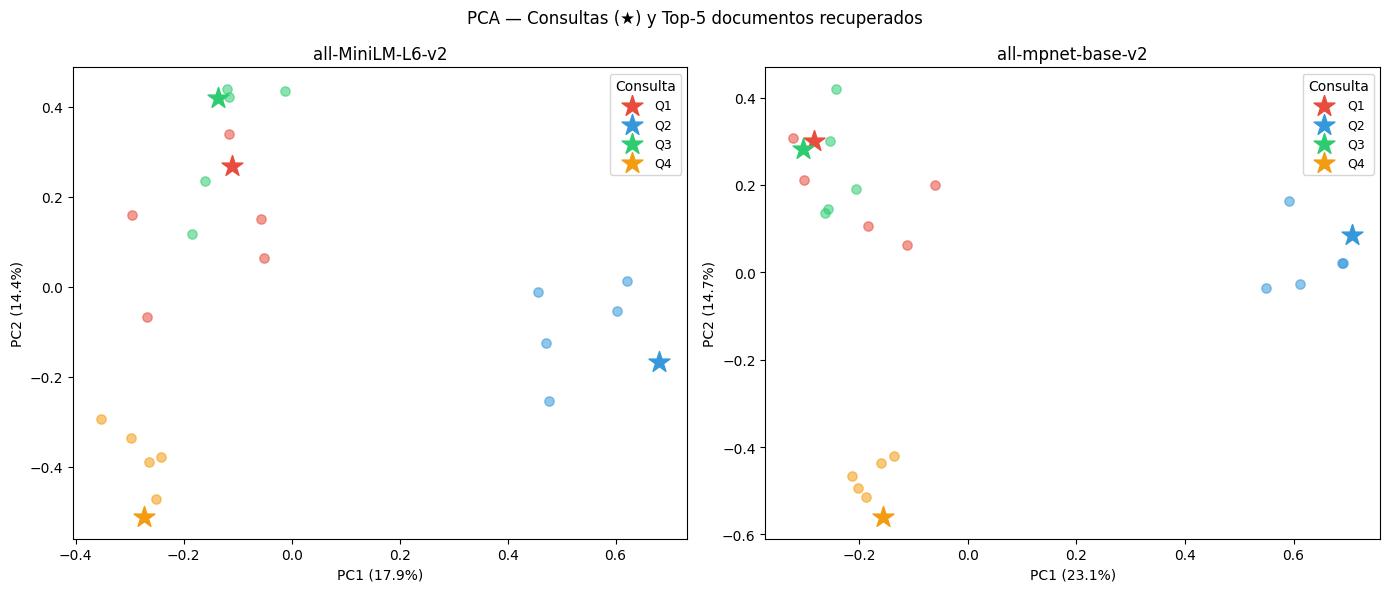

In [33]:
selected = ['Q1', 'Q2', 'Q3', 'Q4']
colors   = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (emb_mat, mdl, res_dict, mname) in zip(axes, [
    (embeddings,  model,  results,  'all-MiniLM-L6-v2'),
    (embeddings2, model2, results2, 'all-mpnet-base-v2')
]):
    vecs, tags = [], []
    for qid in selected:
        vecs.append(mdl.encode([preprocess(queries[qid])])[0])
        tags.append((qid, True))
        for r in res_dict[qid][:5]:
            vecs.append(emb_mat[r['doc_id']])
            tags.append((qid, False))

    pca    = PCA(n_components=2)
    coords = pca.fit_transform(np.array(vecs))
    var    = pca.explained_variance_ratio_

    for i, qid in enumerate(selected):
        idx_q = [j for j, (q, iq) in enumerate(tags) if q == qid and iq]
        idx_d = [j for j, (q, iq) in enumerate(tags) if q == qid and not iq]
        ax.scatter(coords[idx_q, 0], coords[idx_q, 1], marker='*', s=250, color=colors[i], label=qid, zorder=5)
        ax.scatter(coords[idx_d, 0], coords[idx_d, 1], marker='o', s=45,  color=colors[i], alpha=0.55)

    ax.set_title(mname)
    ax.set_xlabel('PC1 (' + str(round(var[0]*100, 1)) + '%)')
    ax.set_ylabel('PC2 (' + str(round(var[1]*100, 1)) + '%)')
    ax.legend(title='Consulta', fontsize=9)

plt.suptitle('PCA — Consultas (★) y Top-5 documentos recuperados')
plt.tight_layout()
plt.savefig('pca_embeddings.png', dpi=100, bbox_inches='tight')
plt.show()

## Conclusiones Generales de la Comparativa

- **all-mpnet-base-v2** obtiene una similitud coseno promedio de **0.656** vs **0.616** de all-MiniLM-L6-v2
- La diferencia de ~4% indica que el modelo más grande captura mejor las relaciones semánticas sutiles
- Ambos modelos manejan consultas generales con coherencia, pero mpnet-base-v2 es más preciso, como sep uede ver en la dispercion de sus puntos en la grafica